In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.2 MB/s eta 0:00:00


In [2]:
# ==============================
# 1. IMPORT LIBRARY
# ==============================
import pandas as pd
import numpy as np
import re
import spacy
import optuna
import kagglehub
import shutil
import os
import pickle

from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score

In [15]:
# Download latest version
path = kagglehub.dataset_download("ssssws/spam-email-detection-dataset-clean-and-ml-ready")

print("Path to dataset files:", path)

# Source file from kagglehub download (assuming it contains the csv)
source_file = os.path.join(path, "spam_email_dataset.csv")
destination_file = "/content/spam_email_dataset.csv"

# Move and rename to the requested location
if os.path.exists(source_file):
    shutil.move(source_file, destination_file)
    print(f"File successfully moved to: {destination_file}")
else:
    print("Source file not found in the downloaded directory.")

100%|██████████| 616k/616k [00:00<00:00, 133MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ssssws/spam-email-detection-dataset-clean-and-ml-ready/versions/1
File successfully moved to: /content/spam_email_dataset.csv


In [3]:
# ==============================
# 2. LOAD DATASET
# ==============================
df = pd.read_csv('spam_email_dataset.csv')

# Drop missing values
df = df.dropna(subset=['email_text', 'label'])

# ==============================
# 3. LOAD SPACY MODEL (LEMMATIZATION)
# ==============================
print("Loading spaCy model...")
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

Loading spaCy model...


In [4]:
# ==============================
# 4. PREPROCESSING FUNCTION
# ==============================
def preprocess_text(text):
    text = text.lower()

    # Remove URL & email
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)

    # Remove non alphabet
    text = re.sub(r'[^a-z\s]', '', text)

    doc = nlp(text)

    tokens = [
        token.lemma_
        for token in doc
        if token.is_alpha and not token.is_stop
    ]

    return " ".join(tokens)

print("Preprocessing text...")
df['clean_text'] = df['email_text'].apply(preprocess_text)

Preprocessing text...


In [12]:
df['clean_text'].head()

,clean_text
0,budget review statement claim world star entir...
1,team sync president series today involve lose ...
2,win free urgent offer limited limited urgent u...
3,guarantee click cash offer click guarantee pro...
4,team sync significant property hotel address m...


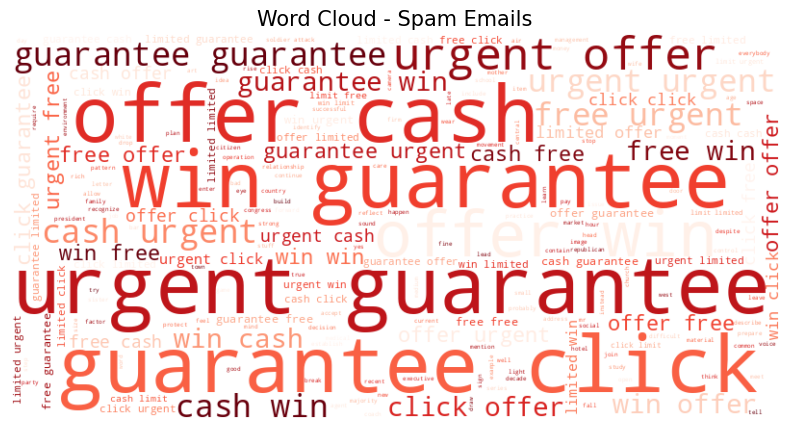

In [13]:
# Filter for spam emails (label 1)
spam_words = ' '.join(df[df['label'] == 1]['clean_text'])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(spam_words)

# Display the plot
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Spam Emails', fontsize=15)
plt.show()

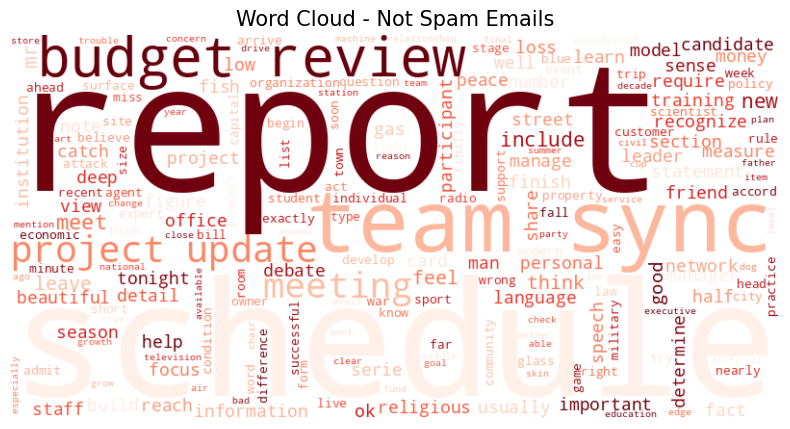

In [14]:
# Filter for not spam emails (label 0)
spam_words = ' '.join(df[df['label'] == 0]['clean_text'])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(spam_words)

# Display the plot
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Not Spam Emails', fontsize=15)
plt.show()

In [5]:
# ==============================
# 5. SPLIT DATA
# ==============================
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
# ==============================
# 6. TF-IDF FEATURE EXTRACTION
# ==============================
print("Extracting TF-IDF features...")

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

Extracting TF-IDF features...


In [7]:
# ==============================
# 7. BASELINE MODEL
# ==============================
print("\nTraining Baseline Logistic Regression...")

baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

baseline_model.fit(X_train_tfidf, y_train)
y_pred_base = baseline_model.predict(X_test_tfidf)

print("\n=== BASELINE RESULT ===")
print("Accuracy:", accuracy_score(y_test, y_pred_base))
print("F1 Score:", f1_score(y_test, y_pred_base))
print("ROC-AUC:", roc_auc_score(y_test, baseline_model.predict_proba(X_test_tfidf)[:,1]))


Training Baseline Logistic Regression...

=== BASELINE RESULT ===
Accuracy: 1.0
F1 Score: 1.0
ROC-AUC: 1.0


In [8]:
# ==============================
# 8. BAYESIAN OPTIMIZATION (OPTUNA)
# ==============================
print("\nRunning Bayesian Optimization with Optuna...")

def objective(trial):
    C = trial.suggest_float('C', 1e-3, 100, log=True)

    model = LogisticRegression(
        C=C,
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train_tfidf,
        y_train,
        cv=5,
        scoring='f1'
    ).mean()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print("\nBest Parameters:", study.best_params)

[I 2026-04-19 09:15:04,338] A new study created in memory with name: no-name-98e2873e-9e78-415e-9d9d-c0595e49d50a
[I 2026-04-19 09:15:04,404] Trial 0 finished with value: 0.9981191222570533 and parameters: {'C': 0.0018011831387346271}. Best is trial 0 with value: 0.9981191222570533.
[I 2026-04-19 09:15:04,501] Trial 1 finished with value: 1.0 and parameters: {'C': 3.5945508092187572}. Best is trial 1 with value: 1.0.



Running Bayesian Optimization with Optuna...


[I 2026-04-19 09:15:04,618] Trial 2 finished with value: 1.0 and parameters: {'C': 0.09361014930019772}. Best is trial 1 with value: 1.0.
[I 2026-04-19 09:15:04,741] Trial 3 finished with value: 1.0 and parameters: {'C': 77.1447193190902}. Best is trial 1 with value: 1.0.
[I 2026-04-19 09:15:04,845] Trial 4 finished with value: 1.0 and parameters: {'C': 10.12770795507504}. Best is trial 1 with value: 1.0.
[I 2026-04-19 09:15:04,952] Trial 5 finished with value: 1.0 and parameters: {'C': 11.092307213745192}. Best is trial 1 with value: 1.0.
[I 2026-04-19 09:15:05,052] Trial 6 finished with value: 1.0 and parameters: {'C': 0.24159326684659654}. Best is trial 1 with value: 1.0.
[I 2026-04-19 09:15:05,173] Trial 7 finished with value: 1.0 and parameters: {'C': 2.2508019639845185}. Best is trial 1 with value: 1.0.
[I 2026-04-19 09:15:05,295] Trial 8 finished with value: 1.0 and parameters: {'C': 98.47471414987055}. Best is trial 1 with value: 1.0.
[I 2026-04-19 09:15:05,375] Trial 9 finishe


Best Parameters: {'C': 3.5945508092187572}


In [9]:
# ==============================
# 9. TRAIN FINAL MODEL
# ==============================
best_model = LogisticRegression(
    **study.best_params,
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

best_model.fit(X_train_tfidf, y_train)
y_pred = best_model.predict(X_test_tfidf)

In [10]:
# ==============================
# 10. FINAL EVALUATION
# ==============================
print("\n=== FINAL MODEL RESULT ===")

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test_tfidf)[:,1])

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


=== FINAL MODEL RESULT ===
Accuracy: 1.0
F1 Score: 1.0
ROC-AUC: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1201
           1       1.00      1.00      1.00       799

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
# ==============================
# 11. SAVE MODEL FOR STREAMLIT
# ==============================

# Save the best model
model_filename = 'spam_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_model, file)

# Save the TF-IDF Vectorizer
vectorizer_filename = 'tfidf_vectorizer.pkl'
with open(vectorizer_filename, 'wb') as file:
    pickle.dump(tfidf, file)

print(f"Model saved as: {model_filename}")
print(f"Vectorizer saved as: {vectorizer_filename}")

Model saved as: best_model.pkl
Vectorizer saved as: tfidf_vectorizer.pkl
